# Building a Random Forest Classifier Model

### Importing Packages

In [17]:
!pip install cartopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
from scipy.ndimage import gaussian_filter

### Creating a Single DS to Work With

If you want to run this, you need to download each of the 20 .csv files (~ 3.2 GB) available here and upload them *individually* into the local directory. This will take a very long time, though...

https://niuits-my.sharepoint.com/:f:/g/personal/z1953922_students_niu_edu/IgCy_rZWnn4sQ7GfDHASRhvtAWxqrIRSe1bvJR99UkBw_1E?e=IhUZlG

In [5]:
data_dir = Path(".")

files = [data_dir / f'GEFSv12_ref_hail_{year}.csv' for year in range(2000, 2020)]

def load_data(files):
    dfs = []
    for f in files:
        df = pd.read_csv(f, parse_dates=['init_date'])
        df = df[df['lead_time'] == 1]
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

df = load_data(files)

# Let's also define our significant hail category now (>=2" or >= hail_class 3)
df["sig_hail"] = (df["hail_class"] >= 3).astype(int)

In [6]:
df

,year,init_date,lead_time,lat,lon,cape,shear,hail_class,sig_hail
0,2000,2000-05-01 00:00:00,1.0,51.0,-107.00,0.0,35.231506,0.0,0
1,2000,2000-05-01 00:00:00,1.0,51.0,-106.75,0.0,36.458935,0.0,0
2,2000,2000-05-01 00:00:00,1.0,51.0,-106.50,0.0,37.659780,0.0,0
3,2000,2000-05-01 00:00:00,1.0,51.0,-106.25,0.0,38.893764,0.0,0
4,2000,2000-05-01 00:00:00,1.0,51.0,-106.00,0.0,40.016552,0.0,0
...,...,...,...,...,...,...,...,...,...
6667869,2019,2019-05-06 00:00:00,1.0,23.0,-66.00,116.0,30.096525,0.0,0
6667870,2019,2019-05-06 00:00:00,1.0,23.0,-65.75,127.0,30.290813,0.0,0
6667871,2019,2019-05-06 00:00:00,1.0,23.0,-65.50,136.0,30.744709,0.0,0
6667872,2019,2019-05-06 00:00:00,1.0,23.0,-65.25,122.0,31.287374,0.0,0


### Train/Val/Test Split and Model Creation

In [7]:
train = df[df['year'] <= 2013]
val   = df[(df['year'] >= 2014) & (df['year'] <= 2016)]
test  = df[df['year'] >= 2017]

features = ['cape', 'shear']

X_train, y_train = train[features], train['sig_hail']
X_val, y_val = val[features], val['sig_hail']
X_test, y_test = test[features], test['sig_hail']

rf = RandomForestClassifier(n_estimators=50, max_depth=5, max_samples=0.7, min_samples_leaf=5,
                            n_jobs=2, random_state=42, class_weight='balanced_subsample')
rf.fit(X_train, y_train)
rf

RandomForestClassifier(class_weight='balanced_subsample', max_depth=5,
                       max_samples=0.7, min_samples_leaf=5, n_estimators=50,
                       n_jobs=2, random_state=42)

### Using the Validation Subset to Determine the Best Probability Threshold for Identifying Significant Hail

In [8]:
val_prob = rf.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)

best_t, best_f1 = 0, 0

for t in thresholds:
    pred = (val_prob >= t).astype(int)
    f1 = f1_score(y_val, pred)
    print(t, f1)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print('\nBest threshold:', best_t)

0.1 0.007008315280138026
0.15000000000000002 0.008455293522007995
0.20000000000000004 0.013788170130662764
0.25000000000000006 0.016354563758923385
0.30000000000000004 0.017894835488002428
0.3500000000000001 0.019486644323586665
0.40000000000000013 0.021056146013020978
0.45000000000000007 0.02334983994600266
0.5000000000000001 0.02425770308123249
0.5500000000000002 0.025672445614353574
0.6000000000000002 0.029709792104948875
0.6500000000000001 0.03383122830425491
0.7000000000000002 0.04075927249622746
0.7500000000000002 0.045108880062274204
0.8000000000000002 0.05219408467040402
0.8500000000000002 0.04864864864864865
0.9000000000000002 0.0008688097306689834

Best threshold: 0.8000000000000002


### Model Performance Evaluation


**NOTE: This confusion matrix only plots a portion of the data. The rest was done on `TRITON` and the full confusion matrix in the README.**

Classification Report:
              precision    recall  f1-score   support

           0      0.999     0.943     0.970    323786
           1      0.023     0.496     0.043       863

    accuracy                          0.942    324649
   macro avg      0.511     0.719     0.507    324649
weighted avg      0.996     0.942     0.967    324649



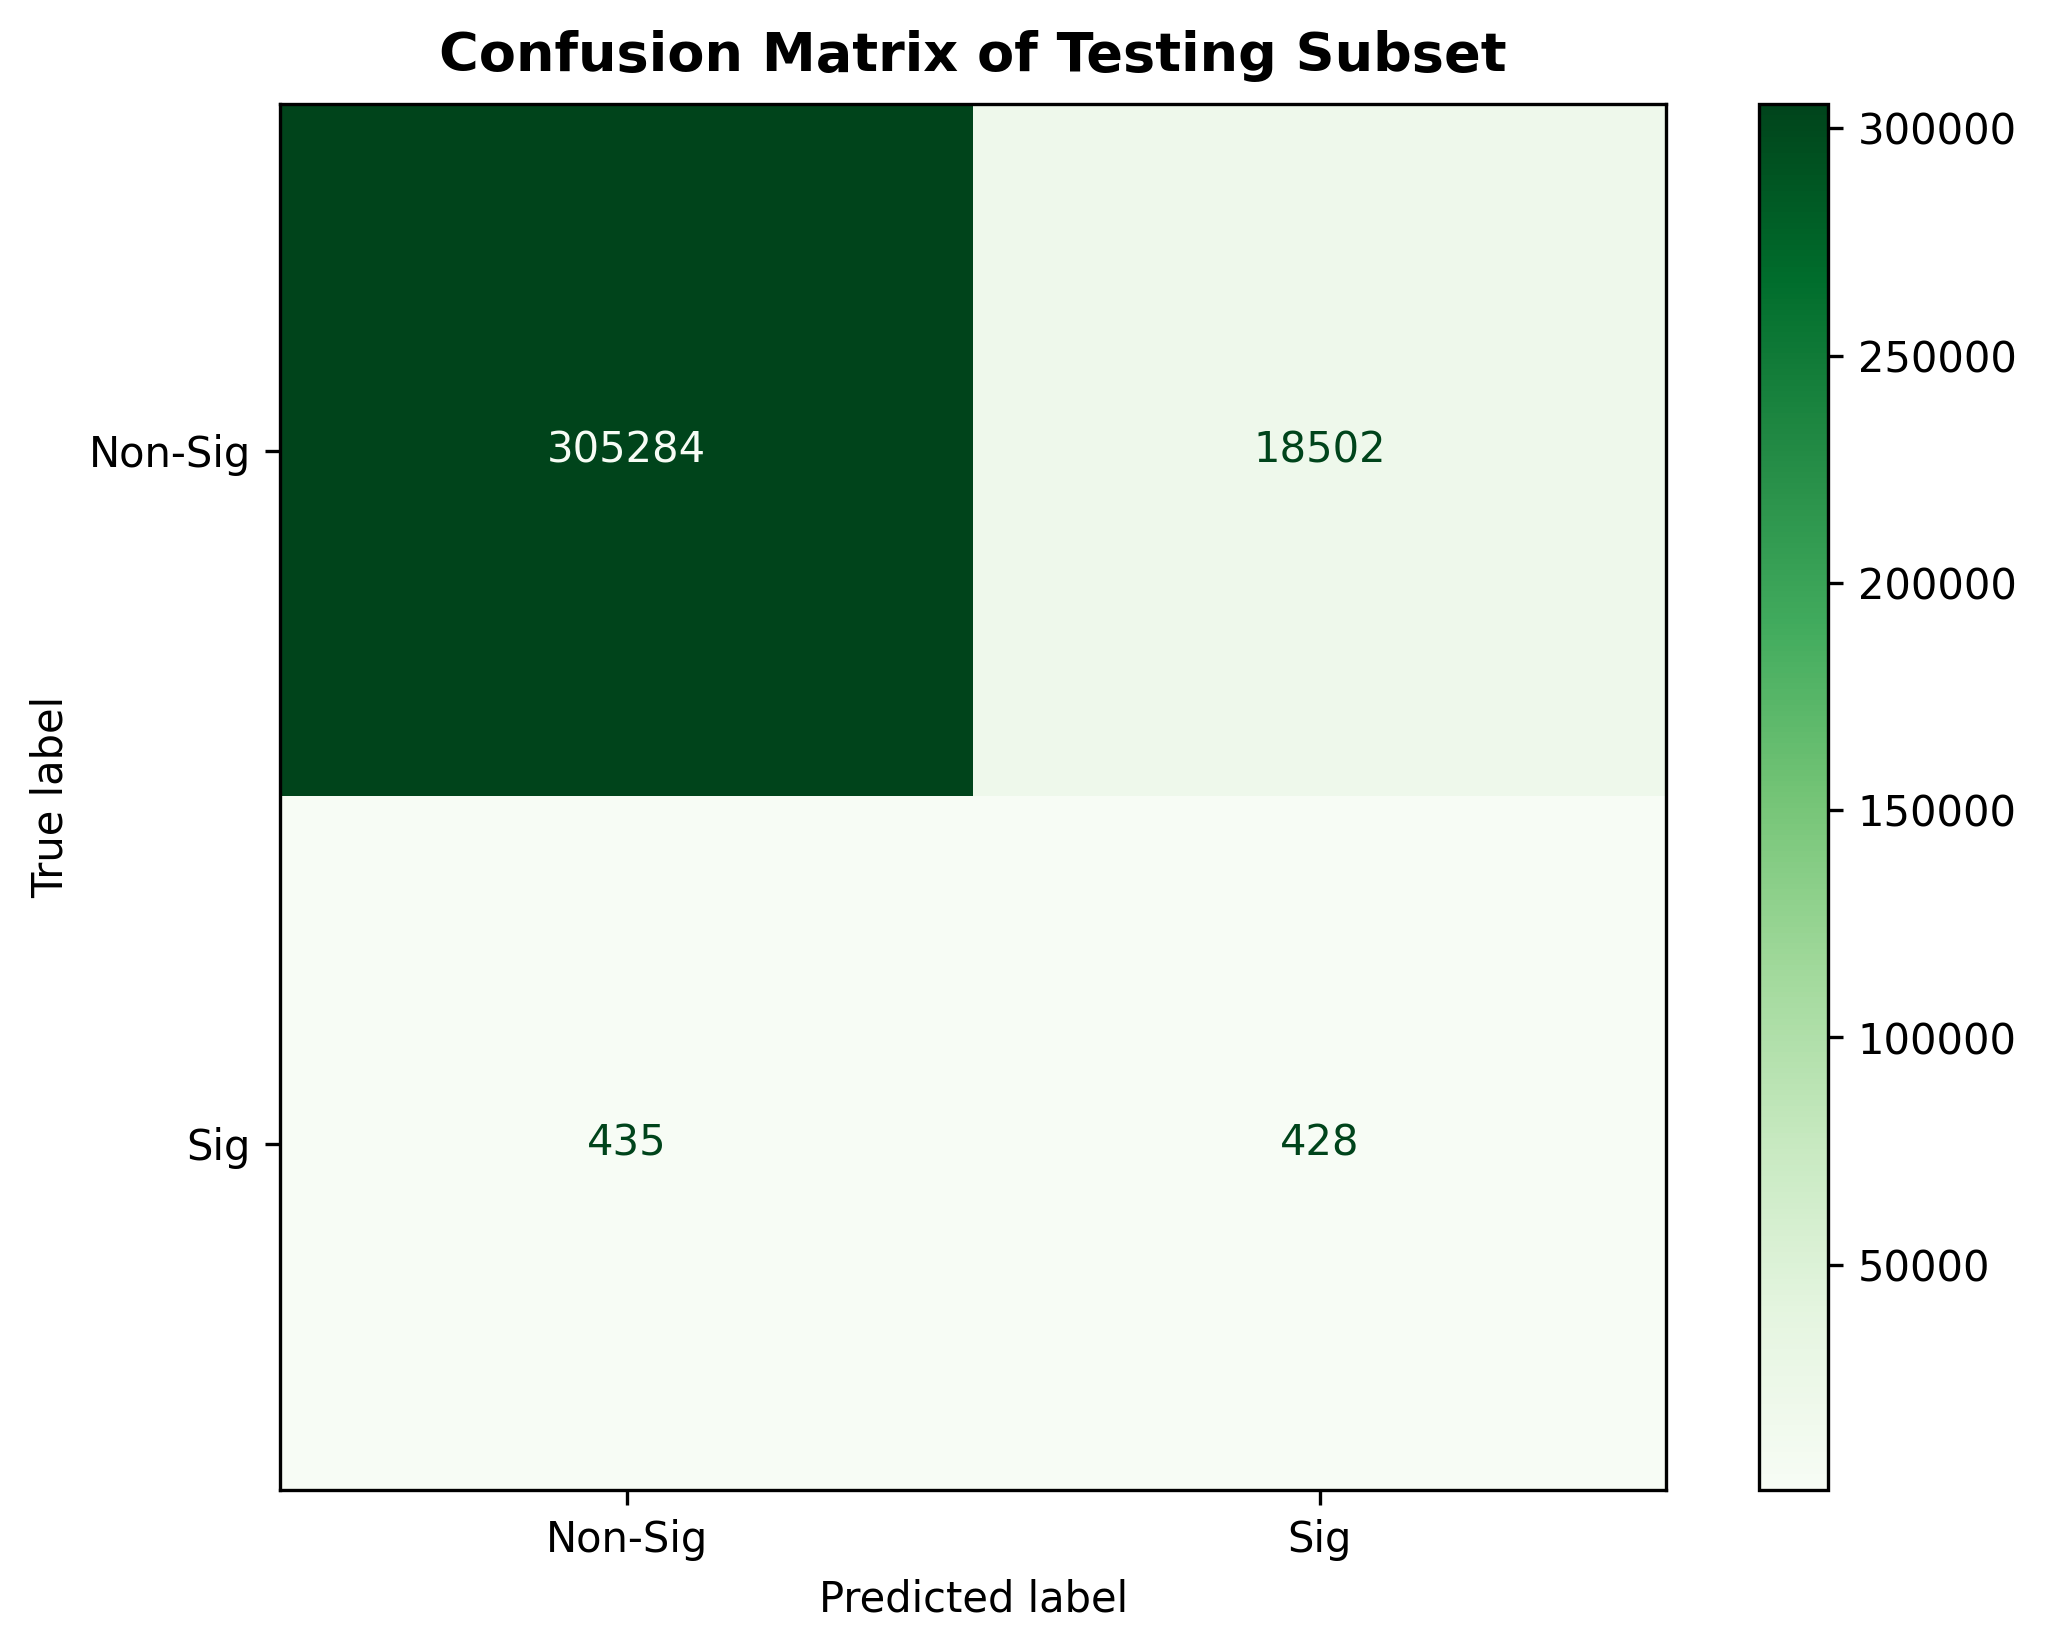

In [10]:
test = test.copy()

test['sig_prob'] = rf.predict_proba(X_test)[:, 1]
test['sig_pred'] = (test['sig_prob'] >= best_t).astype(int)

print('Classification Report:')
print(classification_report(y_test, test['sig_pred'], digits=3))

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
cm = confusion_matrix(y_test, test['sig_pred'])
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Sig', 'Sig'])
display.plot(ax=ax, cmap='Greens')
ax.set_title('Confusion Matrix of Testing Subset', fontsize=13, fontweight='bold', pad=8)

plt.savefig('Confusion_Matrix', dpi=300, bbox_inches='tight')

### Test Subset Maps

Showing init_date: 2019-05-01 00:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


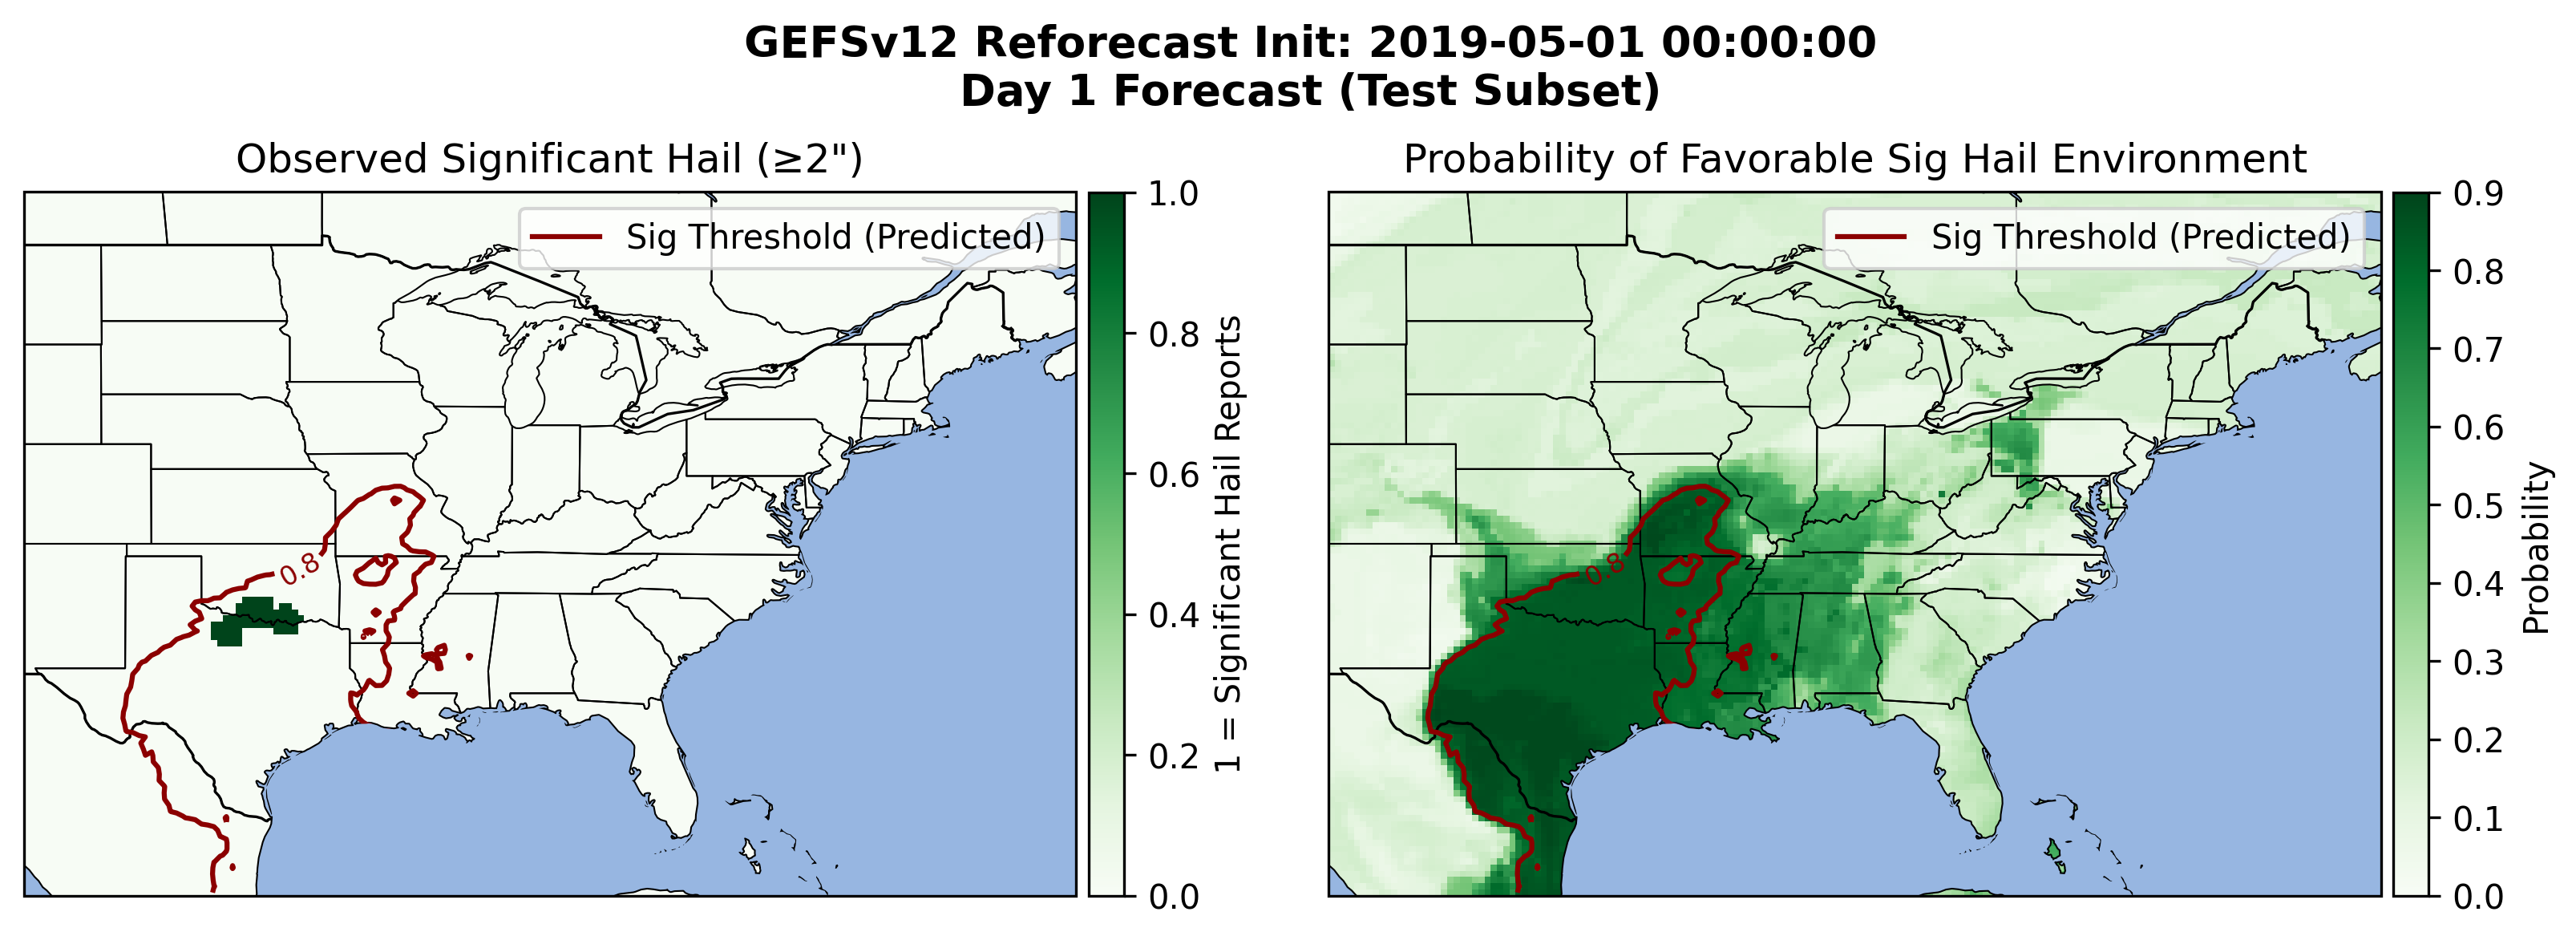

In [14]:
# Getting the days with significant hail
test['init_date'] = pd.to_datetime(test['init_date'], errors='coerce')
hail_days = test.groupby('init_date')['sig_hail'].sum()
hail_days = hail_days[hail_days > 0].index.sort_values()
hail_days_list = list(hail_days)

# Pulls a random sig hail day
day = np.random.choice(hail_days_list)
print(f'Showing init_date: {day}')

df_day = test[test['init_date'] == day]

grid_true = df_day.pivot(index='lat', columns='lon', values='sig_hail')
grid_prob = df_day.pivot(index='lat', columns='lon', values='sig_prob')


fig = plt.figure(figsize=(11, 5), dpi=300)

fig.suptitle(f'GEFSv12 Reforecast Init: {day}\nDay 1 Forecast (Test Subset)', y=0.88, fontsize=13, fontweight='bold')

# Observed significant hail + predicted threshold
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())

mesh1 = ax1.pcolormesh(grid_true.columns, grid_true.index, grid_true.values, transform=ccrs.PlateCarree(),
                       cmap='Greens', vmin=0, vmax=1)

thresh1 = ax1.contour( grid_prob.columns, grid_prob.index, grid_prob.values, levels=[0.8], colors='darkred',
                      linewidths=1.5, transform=ccrs.PlateCarree())
ax1.clabel(thresh1, fmt='0.8', inline=True, fontsize=8)

contour_legend = Line2D([0], [0], color='darkred', lw=1.5, label='Sig Threshold (Predicted)')

ax1.set_title('Observed Significant Hail (≥2\")')
ax1.add_feature(cfeature.STATES, linewidth=0.5)
ax1.add_feature(cfeature.BORDERS, linewidth=0.8)
ax1.add_feature(cfeature.OCEAN, zorder=2)
ax1.coastlines()

cbar1 = plt.colorbar(mesh1, ax=ax1, shrink=0.70, pad=0.01)
cbar1.set_label('1 = Significant Hail Reports')

ax1.legend(handles=[contour_legend], loc='upper right')

# Predicted probability of a favorable significant hail environment + predicted threshold
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

mesh2 = ax2.pcolormesh( grid_prob.columns, grid_prob.index, grid_prob.values, transform=ccrs.PlateCarree(),
                       cmap='Greens', vmin=0, vmax=0.9)

thresh2 = ax2.contour(grid_prob.columns, grid_prob.index, grid_prob.values, levels=[0.8], colors='darkred',
                      linewidths=1.5, transform=ccrs.PlateCarree())
ax2.clabel(thresh2, fmt='0.8', inline=True, fontsize=8)

ax2.set_title('Probability of Favorable Sig Hail Environment')
ax2.add_feature(cfeature.STATES, linewidth=0.5)
ax2.add_feature(cfeature.BORDERS, linewidth=0.8)
ax2.add_feature(cfeature.OCEAN, zorder=2)
ax2.coastlines()

cbar2 = plt.colorbar(mesh2, ax=ax2, shrink=0.70, pad=0.01)
cbar2.set_label('Probability')

ax2.legend(handles=[contour_legend], loc='upper right')

plt.tight_layout()
plt.show()

### Further Sanity Check and Model Evaluation

**NOTE: The plots below here will be slightly different than in the README file. Those in the README are correct, as they were run on `TRITON`.**

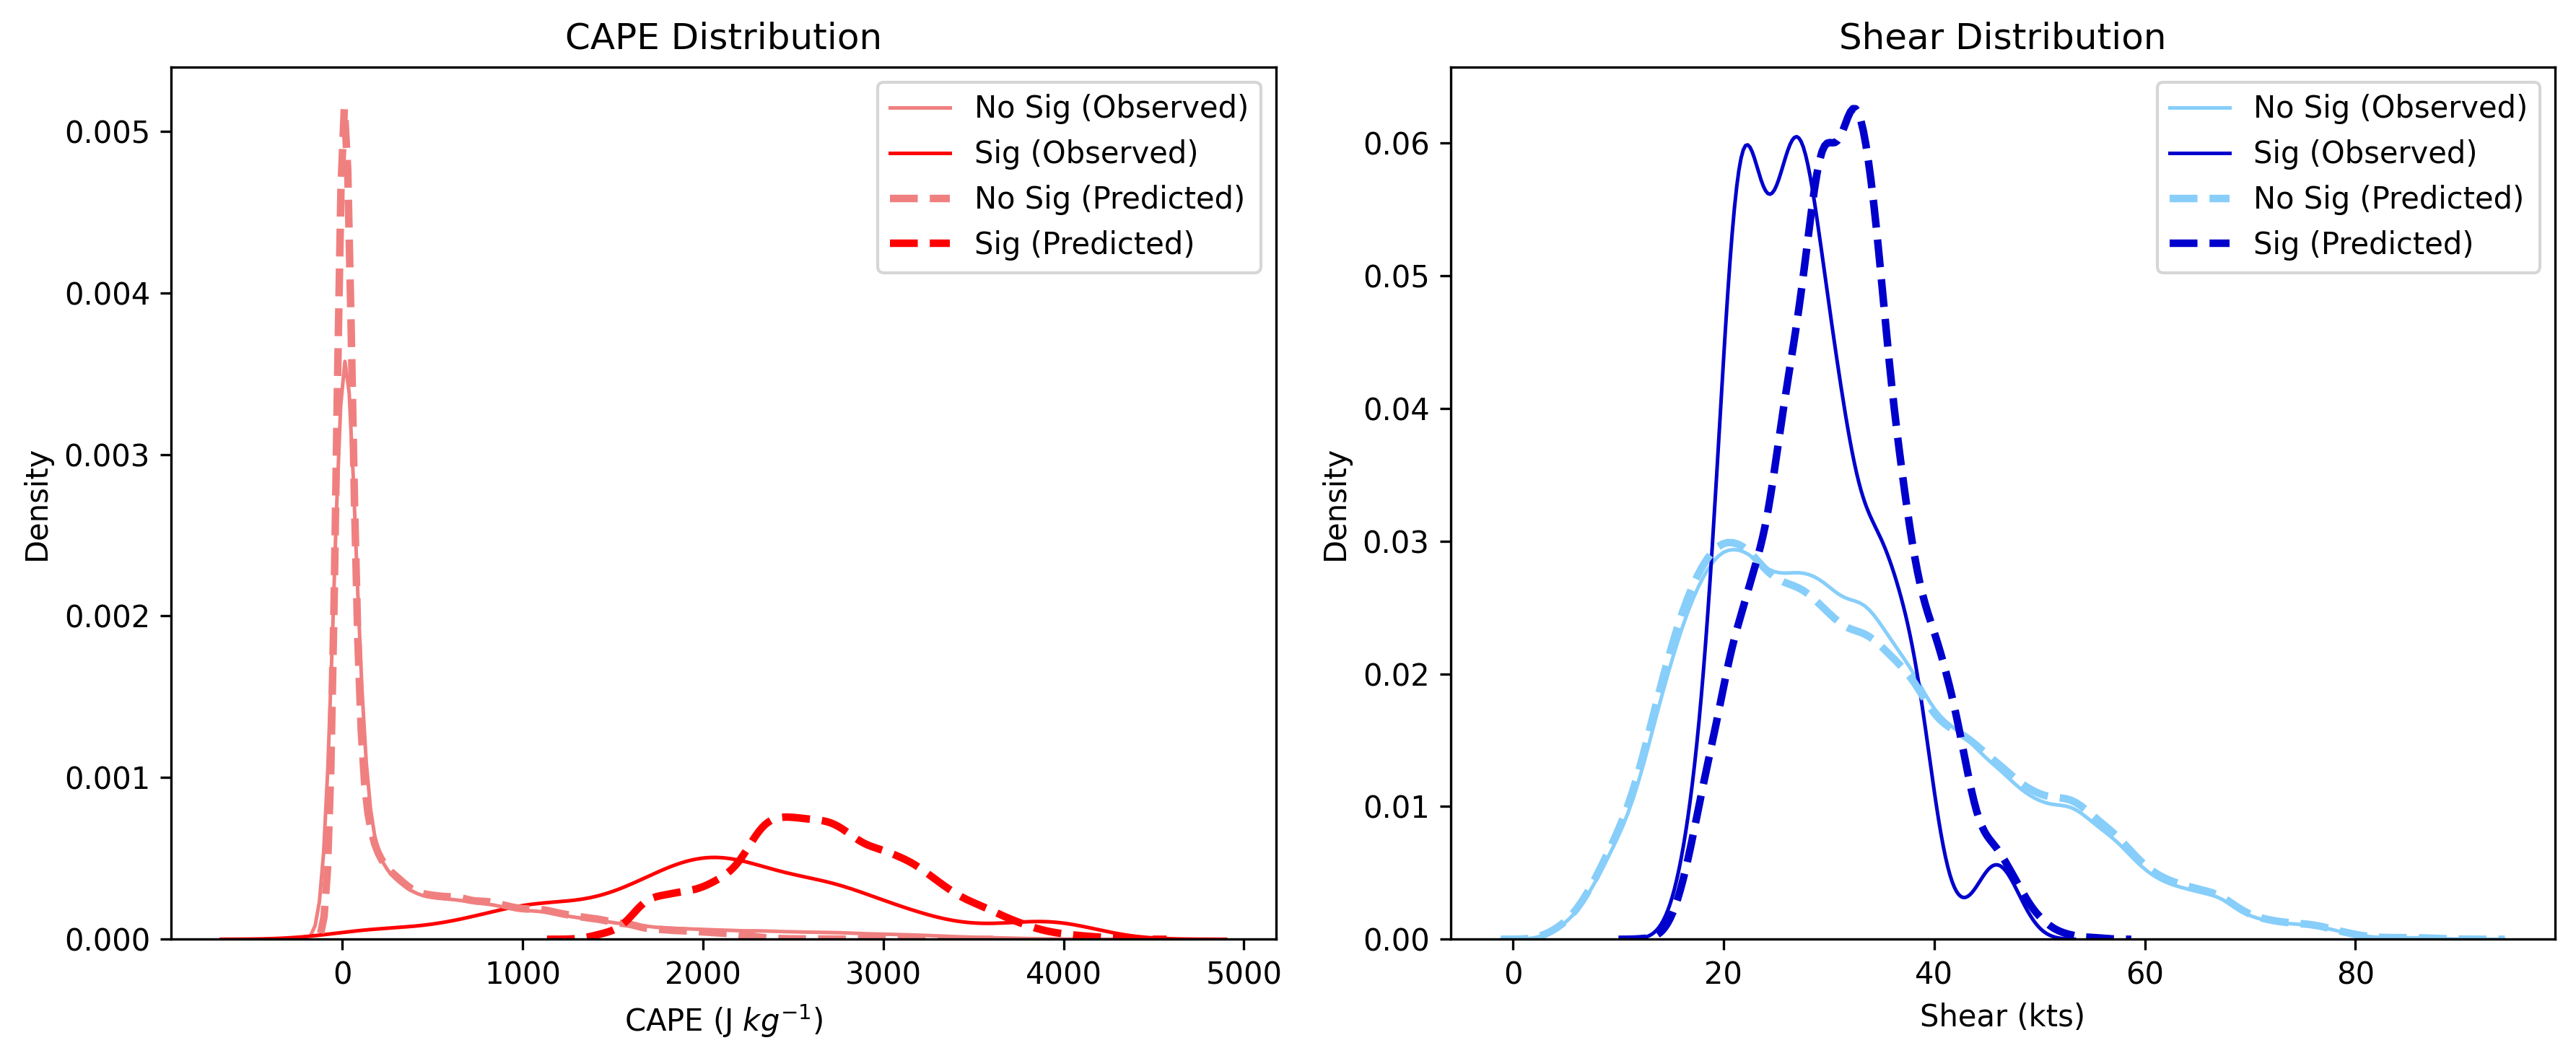

In [16]:
df_plot = test.copy()

# Let's see how the CAPE and Shear distributions compare between observed/predicted and non-sig/sig hail!

warnings.filterwarnings('ignore')

plt.figure(figsize=(12,5), dpi=300)

# CAPE
ax1 = plt.subplot(1,2,1)

# Observed
sns.kdeplot(data=df_plot[df_plot['sig_hail'] == 0], x='cape', ax=ax1, color='lightcoral', label='No Sig (Observed)', lw=1.2)

sns.kdeplot(data=df_plot[df_plot['sig_hail'] == 1], x='cape', ax=ax1, color='red', label='Sig (Observed)', lw=1.2)

# Predicted
sns.kdeplot(data=df_plot[df_plot['sig_hail'] == 0], x='cape', ax=ax1, color='lightcoral', label='No Sig (Predicted)', linestyle='--', lw=2.5)

sns.kdeplot(data=df_plot[df_plot['sig_pred'] == 1], x='cape', ax=ax1, color='red', label='Sig (Predicted)', linestyle='--', lw=2.5)

ax1.set_title('CAPE Distribution')
ax1.set_xlabel('CAPE (J $kg^{-1}$)')
ax1.legend()

# SHEAR
ax2 = plt.subplot(1,2,2)

# Observed
sns.kdeplot(data=df_plot[df_plot['sig_hail'] == 0], x='shear', ax=ax2, color='lightskyblue', label='No Sig (Observed)', lw=1.2)

sns.kdeplot(data=df_plot[df_plot['sig_hail'] == 1], x='shear', ax=ax2, color='mediumblue', label='Sig (Observed)', lw=1.2)

# Predicted
sns.kdeplot(data=df_plot[df_plot['sig_pred'] == 0], x='shear', ax=ax2, color='lightskyblue', label='No Sig (Predicted)', linestyle='--',lw=2.5)

sns.kdeplot(data=df_plot[df_plot['sig_pred'] == 1], x='shear', ax=ax2, color='mediumblue', label='Sig (Predicted)', linestyle='--', lw=2.5)

ax2.set_title('Shear Distribution')
ax2.set_xlabel('Shear (kts)')
ax2.legend()

plt.tight_layout()
plt.savefig('Distribution', dpi=300, bbox_inches='tight')

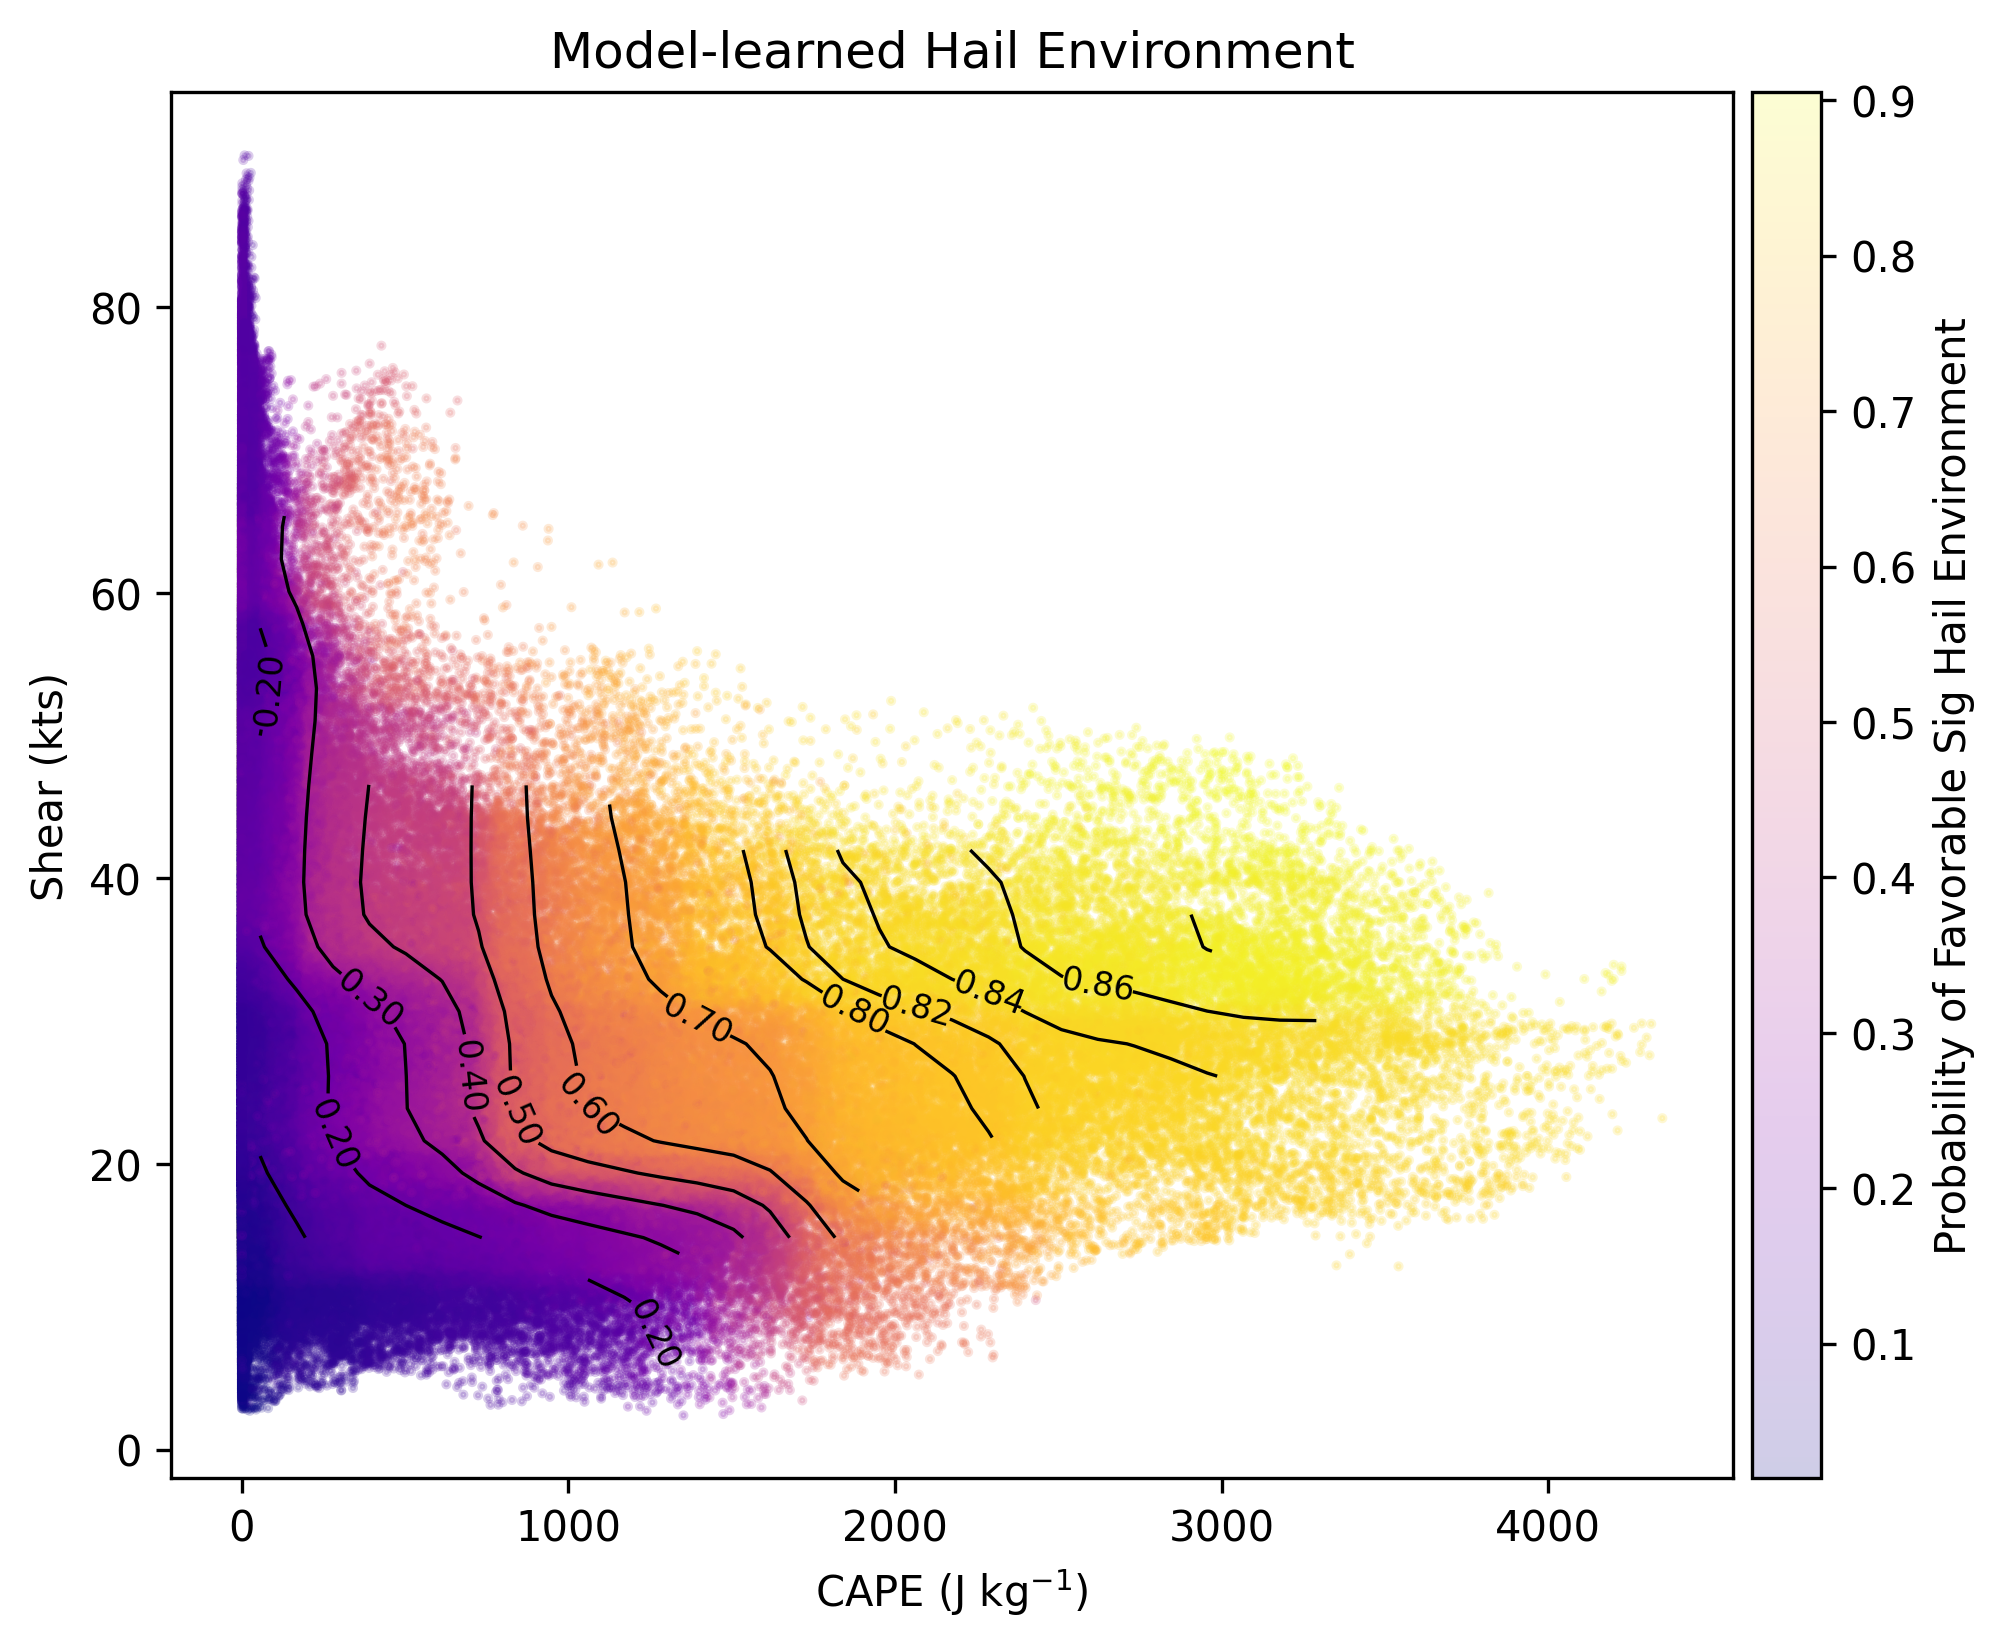

In [18]:
# Finally, let's see how the model learned the relationship between the environmental variables and significant hail probability

# Need to make bins first
cape_bins = np.linspace(df_plot['cape'].min(), df_plot['cape'].max(), 40)
shear_bins = np.linspace(df_plot['shear'].min(), df_plot['shear'].max(), 40)

df_plot['cape_bin'] = pd.cut(df_plot['cape'], cape_bins)
df_plot['shear_bin'] = pd.cut(df_plot['shear'], shear_bins)

grid = df_plot.pivot_table(index='shear_bin', columns='cape_bin', values='sig_prob', aggfunc='mean')

cape_centers = [b.mid for b in grid.columns]
shear_centers = [b.mid for b in grid.index]

grid = gaussian_filter(grid.values, sigma=1)
sig_prob = gaussian_filter(df_plot['sig_prob'].values, sigma=1)

plt.figure(figsize=(8, 6), dpi=300)

# Probability colored beneath the probability contours
sc = plt.scatter(df_plot['cape'], df_plot['shear'], c=sig_prob, cmap='plasma', s=2, alpha=0.2)
cs = plt.contour(cape_centers, shear_centers, grid, levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.82, 0.84, 0.86, 0.88], colors='black', linewidths=0.8)

plt.clabel(cs, inline=True, fontsize=8)

plt.xlabel('CAPE (J kg$^{-1}$)')
plt.ylabel('Shear (kts)')
plt.title('Model-learned Hail Environment')
plt.colorbar(sc, label='Probability of Favorable Sig Hail Environment', pad=0.01)

plt.savefig('Learned_Environment', dpi=300, bbox_inches='tight')